<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720       

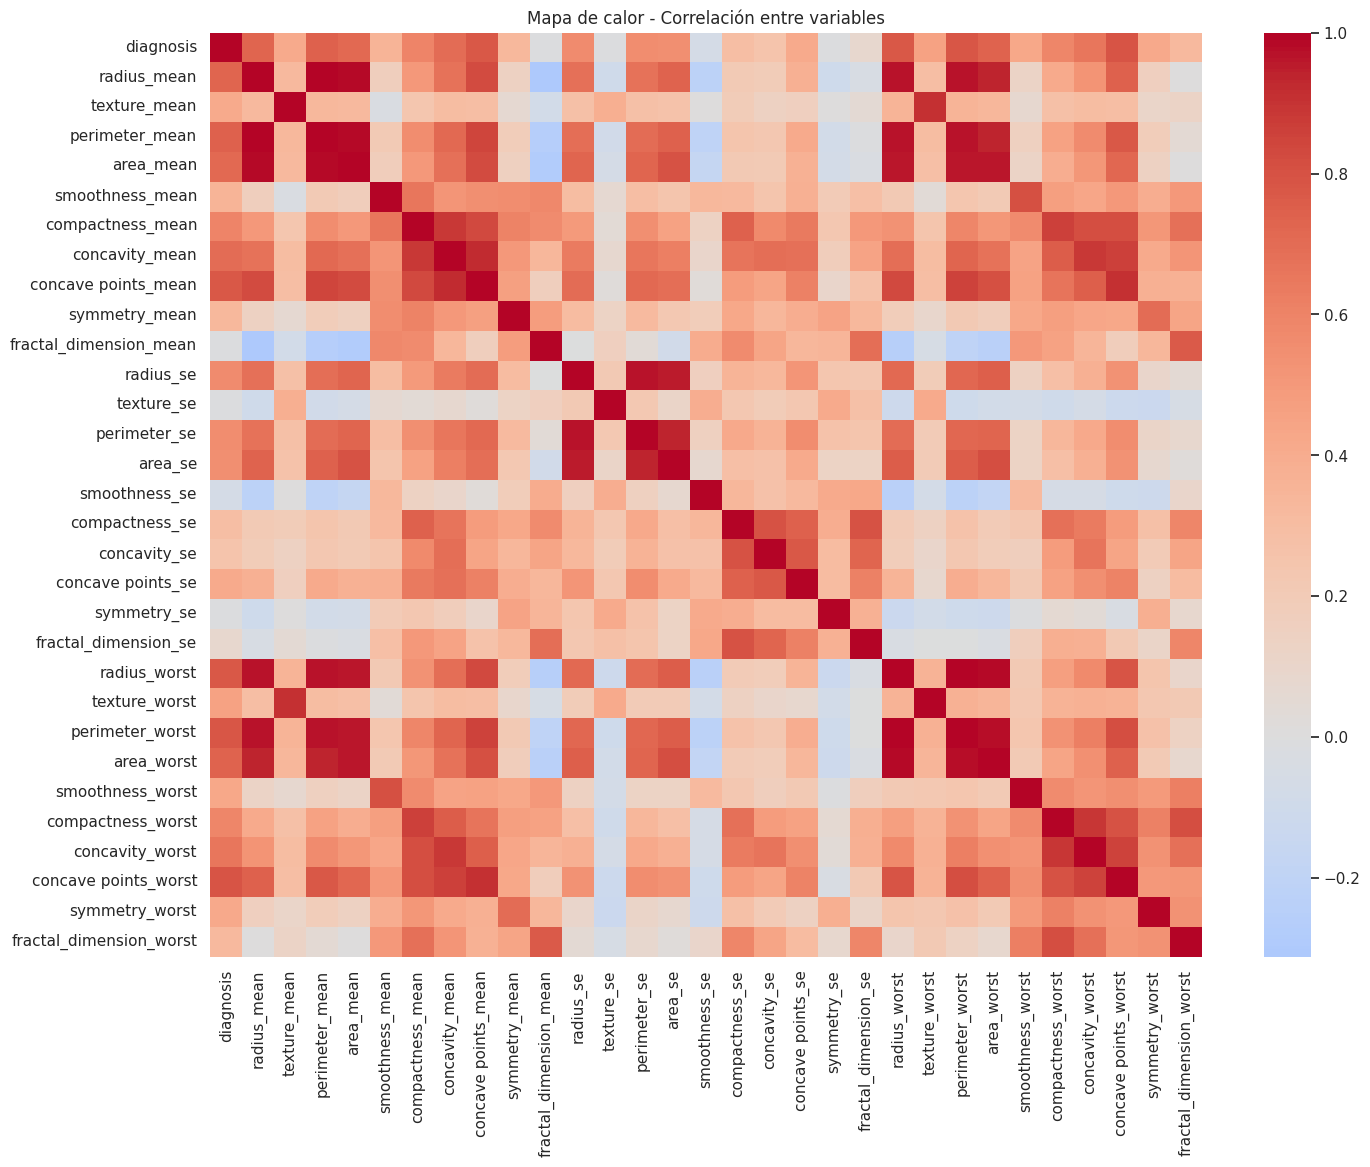

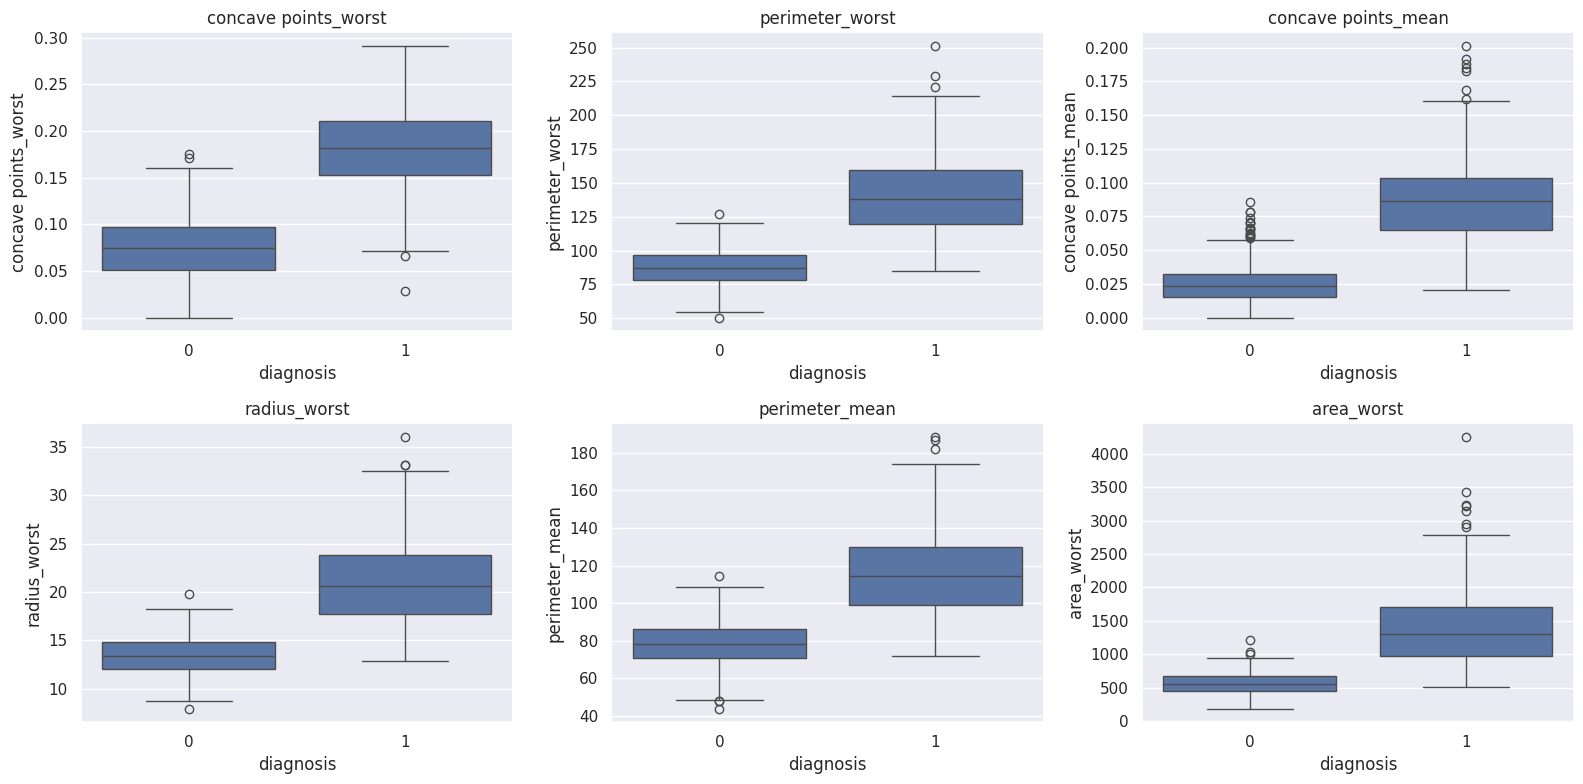

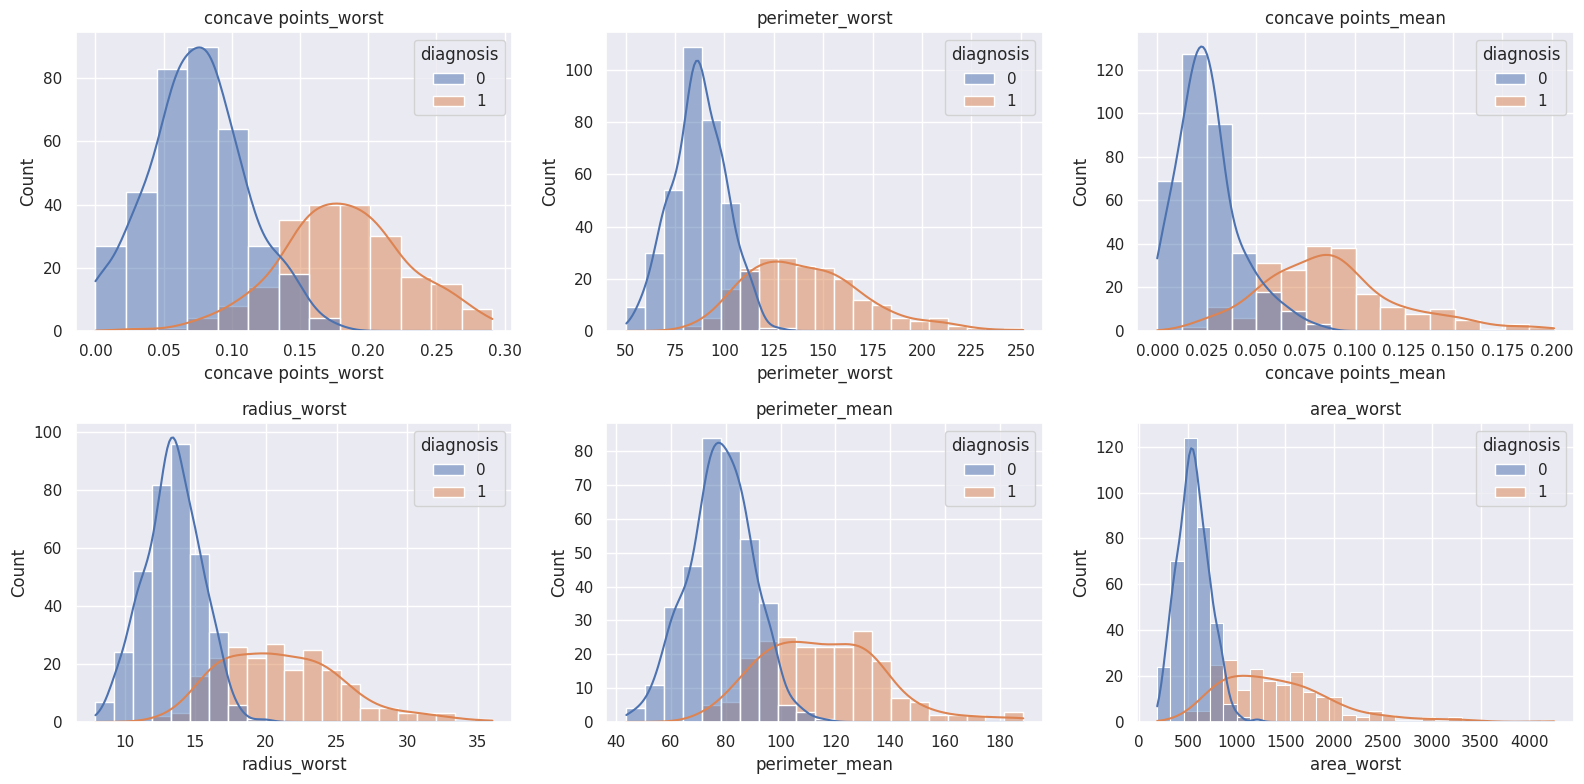

In [3]:

print(df.describe())

corr_target = df.corr()['diagnosis'].sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Mapa de calor - Correlación entre variables')
plt.show()

top_vars = corr_target.drop('diagnosis').abs().sort_values(ascending=False).head(6).index
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axs.flat, top_vars):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axs.flat, top_vars):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=ax, palette='deep')
    ax.set_title(col)
plt.tight_layout()
plt.show()

no hay valores nulos, pero sí outliers en variables como area_mean y concavity_mean. Las variables con mayor capacidad discriminativa son concave points_worst (r≈0.79), perimeter_worst, concave points_mean, radius_worst y perimeter_mean (todas con correlación >0.73 con el diagnóstico); los tumores malignos muestran sistemáticamente valores más altos en tamaño (radio, perímetro, área) y en irregularidad de contorno (concavidad, puntos cóncavos).


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [5]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Variables eliminadas por colinealidad:", to_drop)

X_reduced = X.drop(columns=to_drop)

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Variables eliminadas por colinealidad: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']


se usa StandardScaler porque las variables tienen escalas muy distintas (ej. area_mean en cientos vs smoothness_mean en centésimas), lo cual afecta a modelos basados en distancias (SVM, KNN) y a la regresión logística regularizada. Además, se eliminaron 7 variables (perimeter_mean, area_mean, perimeter_se, area_se, radius_worst, perimeter_worst, area_worst) por tener correlación >0.95 con otras (son medidas redundantes del tamaño del tumor), reduciendo de 30 a 23 variables y disminuyendo el riesgo de multicolinealidad.


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


Varianza explicada: [0.43506016 0.13711137]
Varianza acumulada: 0.5721715284778155


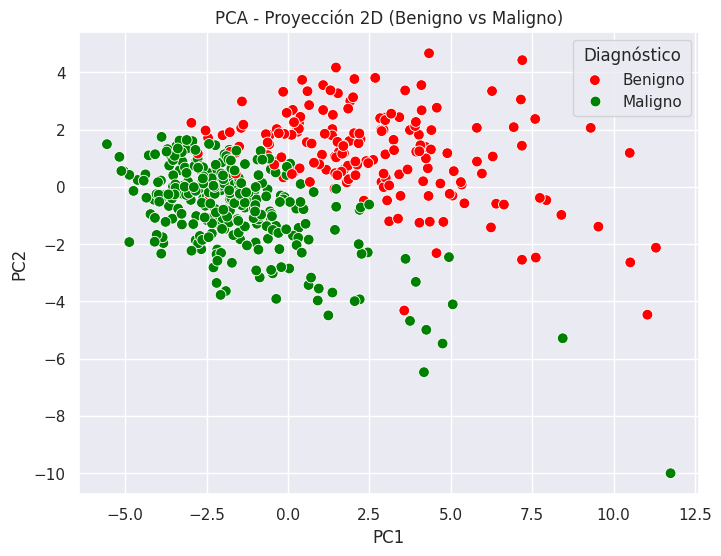

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza acumulada:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette={0: 'green', 1: 'red'}, s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Proyección 2D (Benigno vs Maligno)')
plt.legend(title='Diagnóstico', labels=['Benigno', 'Maligno'])
plt.show()

Con solo 2 componentes se explica cerca del 57% de la varianza (PC1≈43.5%, PC2≈13.7%), y aun así se observa una separación bastante clara entre tumores benignos y malignos en el espacio proyectado, aunque con cierta zona de solapamiento entre ambas clases — lo que anticipa que un clasificador simple (como regresión logística) puede funcionar razonablemente bien, aunque no perfectamente, con esta información reducida.


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.


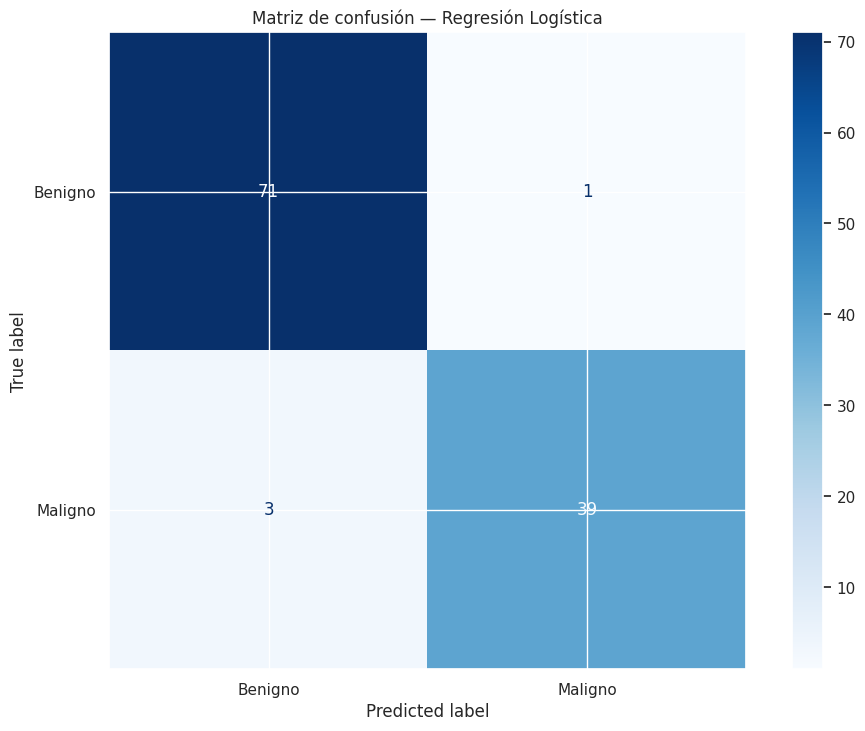

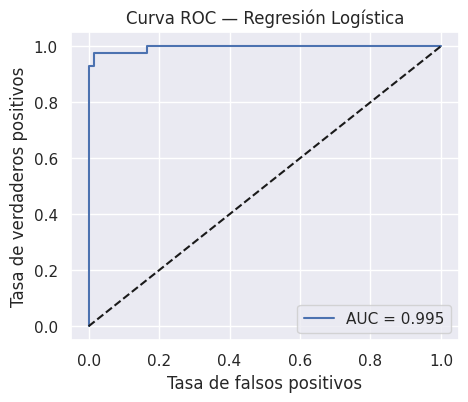

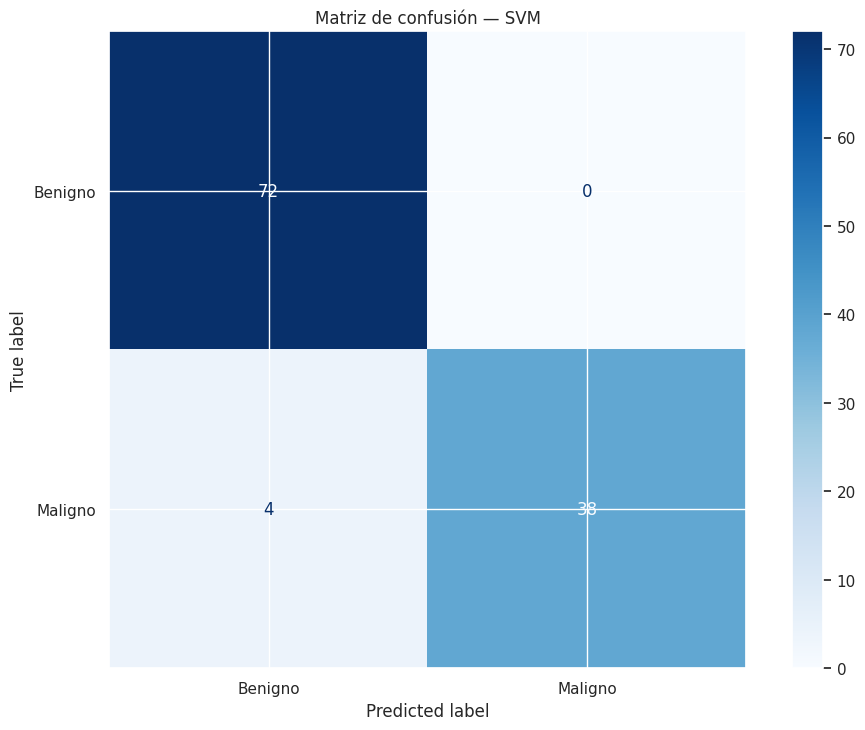

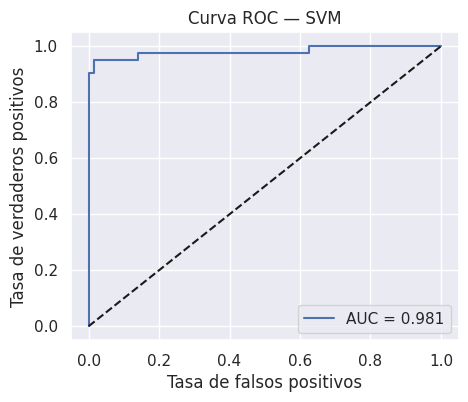

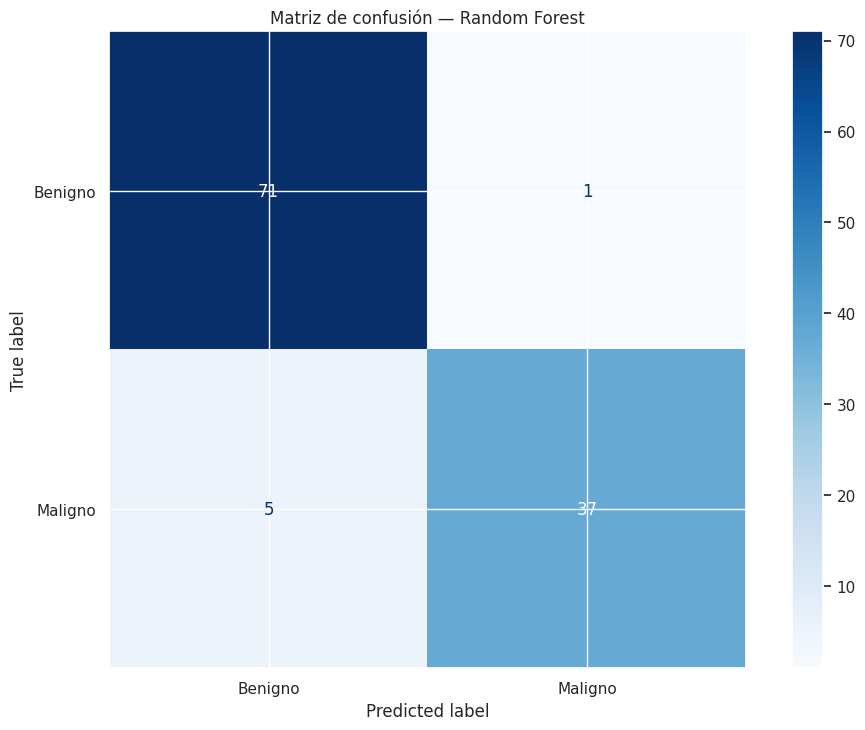

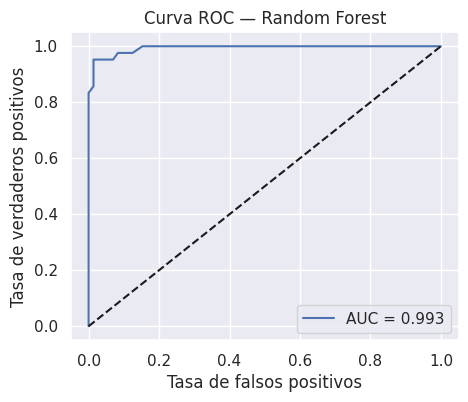

                modelo                            mejores_params  accuracy  \
0  Regresión Logística                                  {'C': 1}  0.964912   
1                  SVM             {'C': 10, 'kernel': 'linear'}  0.964912   
2        Random Forest  {'max_depth': None, 'n_estimators': 100}  0.947368   

   precision    recall       f1       auc  
0   0.975000  0.928571  0.95122  0.995370  
1   1.000000  0.904762  0.95000  0.981151  
2   0.973684  0.880952  0.92500  0.993386  


In [10]:
modelos_params = {
    'Regresión Logística': (LogisticRegression(max_iter=5000),
                             {'C': [0.01, 0.1, 1, 10]}),
    'SVM': (SVC(probability=True),
            {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    'Random Forest': (RandomForestClassifier(random_state=42),
                       {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}),
}

resultados = []
for nombre, (modelo, params) in modelos_params.items():
    grid = GridSearchCV(modelo, params, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    mejor = grid.best_estimator_
    y_pred = mejor.predict(X_test_scaled)
    y_proba = mejor.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    resultados.append({
        'modelo': nombre,
        'mejores_params': grid.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': auc_score
    })

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno']).plot(cmap='Blues')
    plt.title(f'Matriz de confusión — {nombre}')
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Tasa de falsos positivos')
    plt.ylabel('Tasa de verdaderos positivos')
    plt.title(f'Curva ROC — {nombre}')
    plt.legend()
    plt.show()

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados)

Regresión Logística logra el mejor AUC (≈0.995) y muy buen F1; Random Forest queda muy cerca (AUC≈0.993); SVM también funciona bien pero levemente por debajo (AUC≈0.981). Los tres modelos superan el 95% de accuracy, lo cual es esperable dado que las clases están bien separadas tras el preprocesamiento.



5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



In [11]:
print(tabla_resultados.sort_values('f1', ascending=False))

                modelo                            mejores_params  accuracy  \
0  Regresión Logística                                  {'C': 1}  0.964912   
1                  SVM             {'C': 10, 'kernel': 'linear'}  0.964912   
2        Random Forest  {'max_depth': None, 'n_estimators': 100}  0.947368   

   precision    recall       f1       auc  
0   0.975000  0.928571  0.95122  0.995370  
1   1.000000  0.904762  0.95000  0.981151  
2   0.973684  0.880952  0.92500  0.993386  


la Regresión Logística resulta la mejor opción para este dataset: obtiene el mejor (o casi mejor) desempeño en todas las métricas, es computacionalmente ligera, y —crucial en un contexto médico— es interpretable (sus coeficientes indican qué variables aumentan o disminuyen la probabilidad de malignidad), a diferencia de Random Forest o SVM con kernel no lineal, que son más "caja negra". El preprocesamiento (normalización + eliminación de colinealidad) fue clave para que modelos sensibles a la escala (SVM, regresión logística regularizada) funcionaran bien; la PCA ayudó principalmente para visualización y confirmar que las clases son separables, aunque para el modelado final se usaron las variables originales (post-limpieza) en vez de los componentes, priorizando interpretabilidad sobre compresión. Como mejoras futuras en un escenario clínico real: usar validación cruzada anidada para una estimación más robusta del error, priorizar recall sobre precisión (es más costoso un falso negativo que un falso positivo en diagnóstico de cáncer), y considerar métodos de interpretabilidad como SHAP para explicar predicciones individuales a los médicos